<a href="https://colab.research.google.com/github/Sina-Haz/fastai-kaggle/blob/main/Titanic-Random-Forests.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Lets use fastkaggle and random forest models
!pip install -Uq fastkaggle
!pip install -Uq fastai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 774.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 75.0 MB/s eta 0:00:00


In [2]:
import os

os.environ['KAGGLE_USERNAME'] = 'shazeghi'
os.environ['KAGGLE_KEY'] = '87607fda13bdf94dc22bbf70ef2383fb'

In [3]:
from fastkaggle import *
import pandas as pd
import numpy as np

path = setup_comp('titanic', install = 'fastai')
df = pd.read_csv(path/'train.csv')
tst_df = pd.read_csv(path/'test.csv')

# Use the modes to fill empty data values
modes = df.mode().iloc[0]
modes

,0
PassengerId,1
Survived,0.0
Pclass,3.0
Name,"Abbing, Mr. Anthony"
Sex,male
Age,24.0
SibSp,0.0
Parch,0.0
Ticket,1601
Fare,8.05


Light preprocessing

In [4]:
def proc_data(df):
  # Fill the missing values
    df.fillna(modes, inplace=True)
    # Apply log to fare values to go from long tail to normal distribution
    df['LogFare'] = np.log1p(df['Fare'])
    # Classify these variables categorical to change how pandas handles them
    df['Embarked'] = pd.Categorical(df.Embarked)
    df['Sex'] = pd.Categorical(df.Sex)

proc_data(df)
proc_data(tst_df)

Generating Binary Splits

In [5]:
# Lets record which columns are categorical, continuous, and dependent
cats=["Sex","Embarked"]
conts=['Age', 'SibSp', 'Parch', 'LogFare',"Pclass"]
dep="Survived"

In [6]:
df.Sex.head(), df.Sex.cat.codes.head() # now we can access the underlying codes beneath categorical variables

(0      male
 1    female
 2    female
 3    female
 4      male
 Name: Sex, dtype: category
 Categories (2, object): ['female', 'male'],
 0    1
 1    0
 2    0
 3    0
 4    1
 dtype: int8)

<Axes: xlabel='Survived', ylabel='count'>

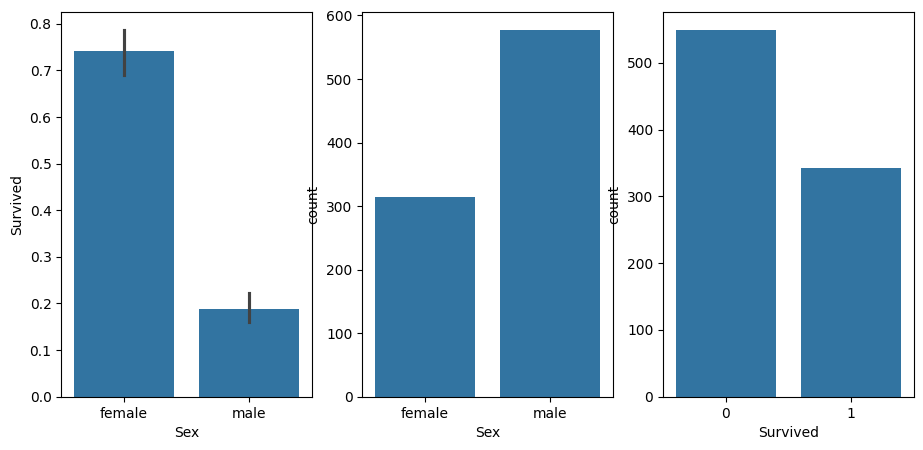

In [7]:
# Use seaborn to visualize our data for binary splits
import matplotlib.pyplot as plt
import seaborn as sns

fig,axs = plt.subplots(1,3, figsize=(11,5))
sns.barplot(data=df, x='Sex', y=dep, ax=axs[0]) # proportion of survivors who are male vs. female
sns.countplot(data=df, x='Sex', ax=axs[1]) # Number of male and female data points
sns.countplot(data=df, x=dep) # Number of people who did not vs did survive

In [8]:
# create a random validation set
from numpy import random
from sklearn.model_selection import train_test_split

random.seed(42)
trn_df,val_df = train_test_split(df, test_size=0.25)

# Bring out the numeric values for our splits and for the tst_df
trn_df[cats] = trn_df[cats].apply(lambda x: x.cat.codes)
val_df[cats] = val_df[cats].apply(lambda x: x.cat.codes)
tst_df[cats] = tst_df[cats].apply(lambda x: x.cat.codes)

In [9]:
# Binary predictor is just that whoever is female lives, male dies
preds = val_df.Sex == 0
preds.head()

,Sex
709,False
439,False
840,False
720,True
39,True


In [10]:
# Lets see how we did
from sklearn.metrics import mean_squared_error as mse
mse(val_df[dep], preds)

0.21524663677130046

Creating a TwoR


<Axes: xlabel='Survived', ylabel='LogFare'>

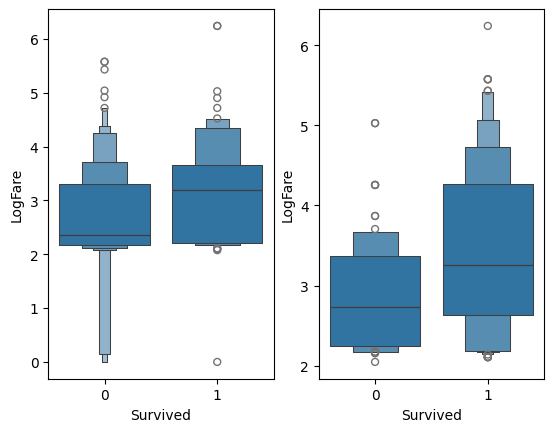

In [11]:
# lets make the next pivot based on logfare
males_idx = trn_df.Sex==1
males, females = trn_df[males_idx], trn_df[~males_idx]

# Show the distribution of logfares people who did and did not survive paid (already split up based on gender)
fig, axs = plt.subplots(1,2)
sns.boxenplot(data=males, x=dep, y = 'LogFare', ax=axs[0])
sns.boxenplot(data=females, x=dep, y = 'LogFare')

In [12]:
# From the plots looks like a good split for males is close to 2.6, for females closer to 2.9
# Implement a TwoR model using this data:

# So first we split data into males and females, this is the OneR rule (first split)
v_males_idx = val_df.Sex == 1 # to get females just do ~ of this

# Next split it based on the fare -> I notice that the higher male fare gets and lower female fare gets the less the MSE (so this feature not doing much rn)
val_logm_idx = val_df.LogFare >= 4
val_logf_idx = val_df.LogFare >= 1

preds = np.zeros(len(val_df))

preds[v_males_idx & val_logm_idx] = 1 # predict that males with higher fare than this survive
preds[~v_males_idx & val_logf_idx] = 1 # predict that females with higher fare than this survive

mse(val_df[dep], preds) # actually does worse than our binary model but to be fair we need to test all possible splits for logfare to get optimal TwoR

0.23318385650224216

In [13]:
# To actually build an optimal tree, we would for a given split, iterate over all features, iterate over all thresholds, evaluate, and recursively repeat
# On the resulting splits from there. Lets implement something like this:

# First implement gini impurity score

def gini(y):
  if len(y) <= 1:
    return 0 # always going to be perfectly pure if there's only 1 thing in the dataset (or its empty)

  _, counts = np.unique(y, return_counts = True) # get's number of each class in the dependent variable
  props = counts / len(y)

  return 1 - np.sum(props ** 2)


gini(val_df[dep]), gini(val_df[val_df.Sex == 1][dep]) # seems to be working since impurity decreases when we split

(np.float64(0.4796396468861228), np.float64(0.3058181054400335))

In [14]:
def get_best_split(df):
  '''
  Returns the best score, feature, and threshold we can get on this df via a binary split
  '''
  X = df.drop(columns=[dep])
  y = df[dep]

  best_score = float('inf')
  best_feature = None
  best_threshold = None

  n = len(y)

  for feature in X.columns:
    unique_vals = sorted(X[feature].unique())

    # Try splitting on every unique value
    for i in range(len(unique_vals) - 1):
      # print(unique_vals[i],unique_vals[i+1])
      thresh = (unique_vals[i] + unique_vals[i+1]) / 2
      # split the data
      rmask = X[feature] <= thresh
      lmask = ~rmask

      # eval each split and see what the weighted sum of them is:
      score = (sum(rmask) * gini(y[rmask]) + sum(lmask) * gini(y[lmask])) / len(y)

      if score < best_score:
        best_score = score
        best_feature = feature
        best_threshold = thresh

  return best_score, best_feature, best_threshold

trn_df = trn_df[cats + conts + [dep]]
val_df = val_df[cats + conts + [dep]]
get_best_split(val_df) # ex. of method in action




(np.float64(0.33549176348254245), 'Sex', np.float64(0.5))

In [15]:
# Now add a class to make decision tree:

class Node:
    """Tree node class to store split information and predictions"""
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature  # splitting feature
        self.threshold = threshold  # splitting threshold
        self.left = left  # left child
        self.right = right  # right child
        self.value = value  # prediction value for leaf nodes

def build_tree(df, max_depth=3, min_samples_split=2, depth=0):
    """
    Recursively build a decision tree

    Args:
        df: Dataframe with X independent and y dependent
        max_depth: maximum depth of the tree
        min_samples_split: minimum samples required to split a node
        depth: current depth in the tree
    Returns:
        Node: root node of the decision tree
    """
    X, y = df.drop(columns=[dep]), df[dep]

    # Check stopping criteria
    if (depth >= max_depth or
        len(y) < min_samples_split or
        len(np.unique(y)) == 1):
        # Create leaf node -> our prediction is whichever number (0 or 1) is more prevalent in our split
        return Node(value=np.bincount(y).argmax())

    # Find best split
    score, feature, threshold  = get_best_split(df)

    # If no good split is found, create a leaf node
    if feature is None:
        return Node(value=np.bincount(y).argmax())

    # Split the data
    left_mask = X[feature] <= threshold
    right_mask = ~left_mask

    # Recursively build left and right subtrees
    left_subtree = build_tree(
        df[left_mask],
        max_depth,
        min_samples_split,
        depth + 1
    )
    right_subtree = build_tree(
        df[right_mask],
        max_depth,
        min_samples_split,
        depth + 1
    )

    return Node(feature=feature, threshold=threshold, left=left_subtree, right=right_subtree)

def predict_single(node, x):
    """Make prediction for a single sample"""
    # if at a leaf node then can stop
    if node.value is not None:
        return node.value

    # Else recursively traverse the tree based on the features of x
    if x[node.feature] <= node.threshold:
        return predict_single(node.left, x)
    else:
        return predict_single(node.right, x)


def predict(df, root, tst=False):
    """Make predictions for multiple samples"""
    return np.array([predict_single(root, row) for _, row in df.drop(columns=[dep]).iterrows()]) if not tst else np.array([predict_single(root, row) for _, row in df.iterrows()])

In [16]:
tree = build_tree(trn_df, max_depth=2) # Build an optimal TwoR

pred = predict(val_df, tree)

mse(val_df[dep], pred) # We see this is much better than our previous TwoR

0.2242152466367713

In [17]:
# Now again whats the best binary split? OneR?
b_split = build_tree(trn_df, max_depth=1)

split_pred = predict(val_df, b_split)

mse(val_df[dep], split_pred) # yep even better!!!

0.21524663677130046

In [18]:
# Let's try a larger decision tree with more splits -> Noticed that after 4 splits the validation mse goes up so it's overfitting
tree = build_tree(trn_df, max_depth=4)

pred = predict(val_df, tree)

mse(val_df[dep], pred)

0.19282511210762332

In [19]:
# Now that we have a tree model and a binary model we can submit to kaggle to see how we did!
import fastkaggle as fk


# we have tst_df which stores data points without a y label -> use preds as the Survived column and remove all the features as the submission
def submit(preds, suffix):
    tst_df['Survived'] = preds
    filename = f"submission_{suffix}.csv"
    tst_df[['PassengerId', 'Survived']].to_csv(filename, index=False)

    # Use Kaggle CLI to submit
    !kaggle competitions submit -c titanic -f {filename} -m "{suffix}"



In [20]:
# Lets submit my 4 depth tree
# preds = predict(tst_df, tree, tst=True)
# submit(preds, '4-depth-tree')

In [21]:
# ! kaggle competitions submissions -c titanic # already nearly as good as our best ensemble MLP models

In [22]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

tree = DecisionTreeClassifier(max_depth=4, min_samples_split=6).fit(trn_df[cats+conts], trn_df[dep])
tree_preds = tree.predict(val_df[cats+conts])

mse(val_df[dep], tree_preds) # since mse same as ours for 4 leaf tree means it did same splits as us and we understand how to make the tree

0.19282511210762332

### Random Forests

As we observed, can't make the decision tree very deep because then there's not enough data supporting splits and it overfits to training data

 - The error can be assumed to be random with mean = 0

 - Therefore, by CLT: average error of a lot of __independent__ trees is normally distributed with mu=0, std inversely prop. to number of trees
  - To achieve independence we use a random subset of training data for each tree

 - So a large "forest" of trees will with high probability produce smaller errors (but this error reduction is asymptotic)



In [35]:
# create a helper function to quickly make a tree based on some proportion of the data
trn_feats = trn_df[cats+conts]
trn_dep = trn_df[dep]
val_feats, val_dep = val_df[cats+conts], val_df[dep]

def make_tree(prop=0.75, depth=4, min_split=6):
  idxs = random.choice(len(trn_feats), int(prop*len(trn_feats)), replace=False)
  trn_x, trn_y = trn_feats.iloc[idxs], trn_dep.iloc[idxs]
  return DecisionTreeClassifier(max_depth=depth, min_samples_split=min_split).fit(trn_x, trn_y)

In [24]:
# Now make as many trees as we want:

trees = [make_tree(prop=.5) for _ in range(1000)]

In [25]:
# make predictions for all datapoints for all trees
preds = np.stack([t.predict(val_df[cats+conts]) for t in trees])

preds.shape

(1000, 223)

In [26]:
# compute mean along axis 0 (along all the trees)
preds = preds.mean(0)

mse(val_df[dep], preds) # So as we can see we get much better results with our random forest!

0.1538916591928251

In [27]:
# sklearn's random forest does mostly the same thing but it also randomizes the columns/features used in each tree

rf = RandomForestClassifier(n_estimators=1000, max_depth=8, min_samples_split=10, n_jobs=-1).fit(trn_feats, trn_dep)

mse(val_df[dep], rf.predict(val_df[cats+conts]))

0.17937219730941703

In [28]:
# let's submit to kaggle to see how this does
preds = np.stack([t.predict(tst_df[cats+conts]) for t in trees])
preds = preds.mean(0)

preds = np.where(preds > 0.5, 1, 0)

submit(preds, 'random_forest2')

100% 2.77k/2.77k [00:00<00:00, 4.45kB/s]
Successfully submitted to Titanic - Machine Learning from Disaster

In [29]:
! kaggle competitions submissions -c titanic # and as you can see we got our highest score yet!

fileName                       date                        description       status                     publicScore  privateScore  
-----------------------------  --------------------------  ----------------  -------------------------  -----------  ------------  
submission_random_forest2.csv  2025-03-29 18:26:00.750000  random_forest2    SubmissionStatus.COMPLETE  0.77990                    
submission_random_forest2.csv  2025-03-25 00:45:42.837000  random_forest2    SubmissionStatus.COMPLETE  0.77990                    
submission_random_forest2.csv  2025-03-24 21:14:44.483000  random_forest2    SubmissionStatus.COMPLETE  0.77990                    
submission_random_forest2.csv  2025-03-24 21:11:02.587000  random_forest2    SubmissionStatus.COMPLETE  0.00000                    
submission_random_forest.csv   2025-03-24 21:10:11.833000  random_forest     SubmissionStatus.COMPLETE  0.77272                    
submission_4-depth-tree.csv    2025-03-24 20:46:26.493000  4-depth-tree     

### Feature Importance

Another great thing about random forests is you can use them to plot feature importance and get a better idea of what was useful and what features can be disregarded

 - This is computed by permutation importance (i.e. shuffling the feature in validation and seeing drop in performance)
 - Can also be computed by seeing how often a feature is used in splits and computing the total (normalized) gini impurity decrease

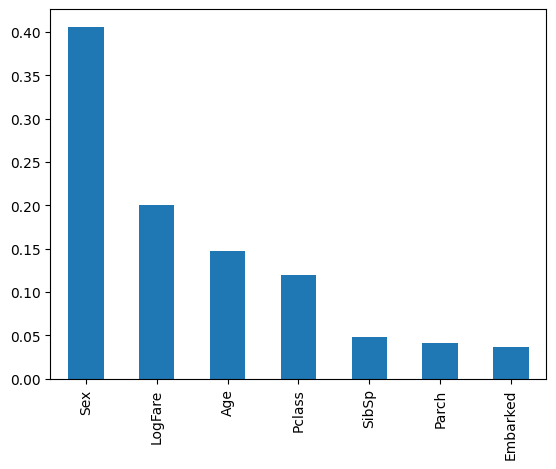

In [30]:
importance = pd.Series(rf.feature_importances_, index=trn_feats.columns).sort_values(ascending=False)

importance.plot.bar();

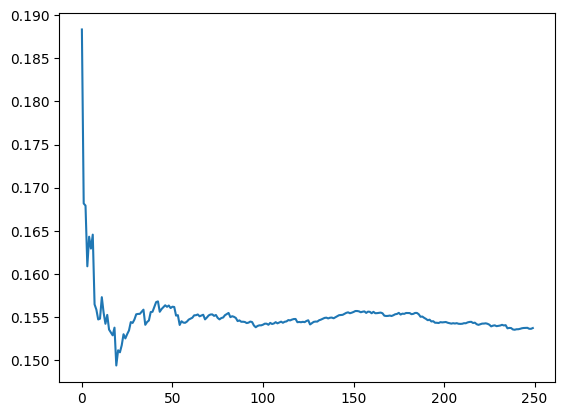

In [31]:
# We can also look at how adding more trees affects our random forest performance:
import matplotlib.pyplot as plt
preds = np.stack([t.predict(val_df[cats+conts]) for t in trees[:250]])

plt.plot([mse(val_df[dep], preds[:i+1].mean(0)) for i in range(len(preds))])

In [32]:
# Can compare validation error to Out of Bag (OOB) error to see if it's from overfitting or some other difference b/w datasets

rf = RandomForestClassifier(n_estimators=100, max_depth=8, min_samples_split=10, n_jobs=-1, oob_score=True).fit(trn_feats, trn_dep)

rf.oob_score_

0.8203592814371258

### Further Model and Data Interpretation

__Partial Dependence Plots__:
 - A good way of determining how a feature affects the dependent variable -> change the feature value and use your model to predict
  - Do this instead of averaging dependent per different feature value
  - Relationship b/w feature and dependent is more clear b/c we are keeping all other features the same (averaging and looking at data doesn't take into acct that features may be correlated)


__Prediction Interpretation__:
 - With tree based models, easy to aggregate how much each variable/feature contributed to our prediction
 - Can easily visualize these contributions with a waterfall plot

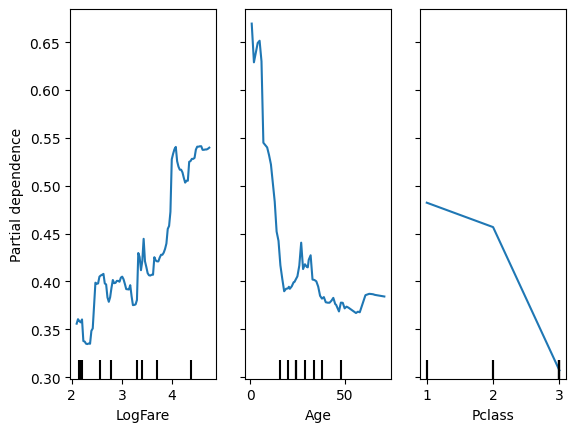

In [39]:
from sklearn.inspection import PartialDependenceDisplay

# Shows the general trends b/w each feature and survival rate, seems like being very young gives highest chance of survival as an individual feature
pd = PartialDependenceDisplay.from_estimator(rf, val_feats, features=['LogFare', 'Age', 'Pclass'])


In [40]:
! pip install -Uq treeinterpreter waterfallcharts

  Preparing metadata (setup.py) ... done
  Created wheel for waterfallcharts: filename=waterfallcharts-3.8-py3-none-any.whl size=3389 sha256=0f2eb0c0c0562e30c96ff591288565f12fe5a552dd6814e1e30ee1d6f810dfb5
  Stored in directory: /root/.cache/pip/wheels/49/9a/ff/ec03fce8e52feb9578e6d919014384cd15a7f1a2d90f56fce9
Successfully built waterfallcharts


In [60]:
from treeinterpreter import treeinterpreter as interpret
from waterfall_chart import plot as wfplt

# Now let's interpret a prediction (more useful during deployment) -> get five features
rows = val_feats.iloc[:5]

# Decomposes model prediction into bias + feature contribution -> therefore sum of bias + contr = pred
pred, bias, contr = interpret.predict(model=rf, X=rows.values)

pred[0,0], bias[0,0] + contr[0, :, 0].sum() # Need to index b/c tree interpreter is reshaping to decompose how much feature is contributing based on n_classes which is 2

(np.float64(0.72354326522372), np.float64(0.7235432652237198))

/usr/local/lib/python3.11/dist-packages/waterfall_chart.py:141: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y = y_height[loop] + row['amount']
/usr/local/lib/python3.11/dist-packages/waterfall_chart.py:139: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y = y_height[loop]


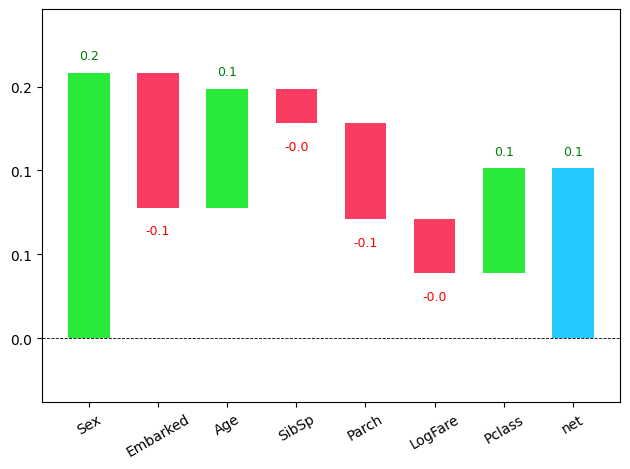

In [62]:
wfplt(index=val_feats.columns, data=contr[0, :, 0], ); # Create a waterfall plot which visualizes how each feature is contributing to the prediction